<a href="https://colab.research.google.com/github/frankZawacki/DSP566GroupProj_Colab/blob/groupProject/DSP566GroupProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
%pip install kagglehub

In [8]:
import kagglehub

In [9]:
!mkdir -p ~/.kaggle
!cp /content/kaggle.json ~/.kaggle/
#!chmod 600 ~/.kaggle/kaggle.json
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

In [10]:
import os
import shutil
# 0a) Prepare Kaggle credentials (only needed once per session)
# Upload kaggle.json to /content (Files tab)
KAGGLE_JSON_SRC = "/content/kaggle.json"
if os.path.exists(KAGGLE_JSON_SRC):
    os.makedirs("/root/.kaggle", exist_ok=True)
    shutil.copy(KAGGLE_JSON_SRC, "/root/.kaggle/kaggle.json")
    os.chmod("/root/.kaggle/kaggle.json", 0o600)



In [11]:
%pip install scikit-learn
%pip install seaborn
%pip install tensorflow
%pip install kagglehub
%pip install kaggle


In [12]:
import kaggle

In [13]:
# ===============================================================
# Brain Tumor MRI Classification (CNN from scratch vs. VGG16 TL)
# Dataset: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
# Jupyter/Colab-ready end-to-end pipeline with comments & explanations.
# ===============================================================

# ── Setup
!pip -q install kaggle seaborn scikit-learn

import os, sys, zipfile, glob, shutil, math, random, itertools, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

# Reproducibility
SEED = 42
tf.random.set_seed(SEED); np.random.seed(SEED); random.seed(SEED)

# ===============================================================
# 0) Download & locate the dataset (Kaggle)
#    -Need a Kaggle API token: upload kaggle.json or mount Drive.
#
# ===============================================================

DATA_ROOT = "/kaggle/input/brain-tumor-mri-dataset"   # where we’ll unzip
os.makedirs(DATA_ROOT, exist_ok=True)
import os # Ensure os is imported for path handling

# --- Configuration (Ensure these match your project's settings) ---
# Assuming these are defined globally or passed into the function context
IMG_HEIGHT = 224 # Standard input size for many pre-trained models
IMG_WIDTH = 224  # Standard input size for many pre-trained models
BATCH_SIZE = 32
EPOCHS = 50 # EarlyStopping will stop training when validation loss plateaus
classification_path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

'''
# 0b) Download the dataset (skip if already present)
KAGGLE_DATASET = "masoudnickparvar/brain-tumor-mri-dataset"
archive_path = os.path.join(DATA_ROOT, "brain-tumor.zip")
if not glob.glob(os.path.join(DATA_ROOT, "**", "Training"), recursive=True):
    !kaggle datasets download -d {KAGGLE_DATASET} -p {DATA_ROOT}
    # Unzip
    with zipfile.ZipFile(archive_path, 'r') as zf:
        zf.extractall(DATA_ROOT)
    print("Unzipped.")
'''

# 0c) Locate the Train/Test directories robustly
def find_train_test(root):
    candidates = []
    for p in glob.glob(os.path.join(root, "**"), recursive=True):
        if os.path.isdir(p):
            sub = [os.path.basename(x).lower() for x in glob.glob(os.path.join(p, "*")) if os.path.isdir(x)]
            if "training" in sub and "testing" in sub:
                candidates.append(p)
    if candidates:
        base = sorted(candidates, key=lambda x: len(x))[0]
        return os.path.join(base, "Training"), os.path.join(base, "Testing")
    # Fallback: search individually
    train_dirs = [d for d in glob.glob(os.path.join(root, "**", "Training"), recursive=True) if os.path.isdir(d)]
    test_dirs  = [d for d in glob.glob(os.path.join(root, "**", "Testing"),  recursive=True) if os.path.isdir(d)]
    if train_dirs and test_dirs:
        return train_dirs[0], test_dirs[0]
    raise FileNotFoundError("Could not locate Training/Testing directories. Please check dataset layout.")

TRAIN_DIR, TEST_DIR = find_train_test(DATA_ROOT)
print("TRAIN_DIR:", TRAIN_DIR)
print("TEST_DIR :", TEST_DIR)

# Peek classes in train
print("Classes (train):", sorted([os.path.basename(p) for p in glob.glob(os.path.join(TRAIN_DIR, "*")) if os.path.isdir(p)]))
'''
def find_train_test(root):
    """Search recursively for 'Training' and 'Testing' directories and return their paths."""
    train_dirs = [p for p in glob.glob(os.path.join(root, "**", "Training"), recursive=True) if os.path.isdir(p)]
    test_dirs  = [p for p in glob.glob(os.path.join(root, "**", "Testing"),  recursive=True) if os.path.isdir(p)]
    if train_dirs and test_dirs:
        # pick shortest path match (usually the real one)
        train_dir = sorted(train_dirs, key=len)[0]
        test_dir  = sorted(test_dirs,  key=len)[0]
        return train_dir, test_dir
    return None, None

# First, see if kagglehub already provided extracted folders
TRAIN_DIR, TEST_DIR = find_train_test(cache_path)

# If not found, extract any zips we see into DATA_ROOT and search again
if TRAIN_DIR is None or TEST_DIR is None:
    zip_files = glob.glob(os.path.join(cache_path, "**", "*.zip"), recursive=True)
    if not zip_files:
        # Sometimes the dataset is a single directory named like "Brain Tumor MRI Dataset"
        # Copy tree over to DATA_ROOT (no-op if already there)
        if cache_path != DATA_ROOT:
            # copy contents (avoid copying into itself)
            for item in os.listdir(cache_path):
                s = os.path.join(cache_path, item)
                d = os.path.join(DATA_ROOT, item)
                if os.path.isdir(s):
                    if os.path.exists(d): shutil.rmtree(d)
                    shutil.copytree(s, d)
                else:
                    shutil.copy2(s, d)
    else:
        for z in zip_files:
            print("Extracting:", z)
            with zipfile.ZipFile(z, 'r') as zf:
                zf.extractall(DATA_ROOT)

    # Try finding again in DATA_ROOT
    TRAIN_DIR, TEST_DIR = find_train_test(DATA_ROOT)

if TRAIN_DIR is None or TEST_DIR is None:
    # One more fallback: if there is a single top folder, search from there
    top_candidates = [p for p in glob.glob(os.path.join(DATA_ROOT, "*")) if os.path.isdir(p)]
    for cand in top_candidates:
        TRAIN_DIR, TEST_DIR = find_train_test(cand)
        if TRAIN_DIR and TEST_DIR:
            break

if TRAIN_DIR is None or TEST_DIR is None:
    raise FileNotFoundError(
        "Could not locate 'Training' and 'Testing' directories after download/extraction.\n"
        f"Please explore contents under: {cache_path} and {DATA_ROOT}"
    )

print("TRAIN_DIR:", TRAIN_DIR)
print("TEST_DIR :", TEST_DIR)


'''

TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TRAIN_DIR: /kaggle/input/brain-tumor-mri-dataset/Training
TEST_DIR : /kaggle/input/brain-tumor-mri-dataset/Testing
Classes (train): ['glioma', 'meningioma', 'notumor', 'pituitary']


'\ndef find_train_test(root):\n    """Search recursively for \'Training\' and \'Testing\' directories and return their paths."""\n    train_dirs = [p for p in glob.glob(os.path.join(root, "**", "Training"), recursive=True) if os.path.isdir(p)]\n    test_dirs  = [p for p in glob.glob(os.path.join(root, "**", "Testing"),  recursive=True) if os.path.isdir(p)]\n    if train_dirs and test_dirs:\n        # pick shortest path match (usually the real one)\n        train_dir = sorted(train_dirs, key=len)[0]\n        test_dir  = sorted(test_dirs,  key=len)[0]\n        return train_dir, test_dir\n    return None, None\n\n# First, see if kagglehub already provided extracted folders\nTRAIN_DIR, TEST_DIR = find_train_test(cache_path)\n\n# If not found, extract any zips we see into DATA_ROOT and search again\nif TRAIN_DIR is None or TEST_DIR is None:\n    zip_files = glob.glob(os.path.join(cache_path, "**", "*.zip"), recursive=True)\n    if not zip_files:\n        # Sometimes the dataset is a single 


Train distribution:
         class  count
0      glioma   1321
1  meningioma   1339
2     notumor   1595
3   pituitary   1457

Test distribution:
         class  count
0      glioma    300
1  meningioma    306
2     notumor    405
3   pituitary    300


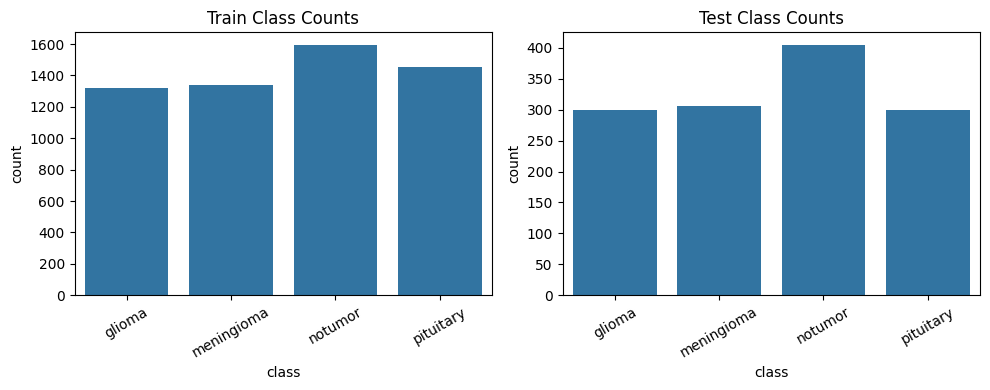

In [14]:
# ===============================================================
# 1) EDA: class distribution
# ===============================================================
def count_images_per_class(folder):
    rows = []
    for cdir in sorted(glob.glob(os.path.join(folder, "*"))):
        if os.path.isdir(cdir):
            cls = os.path.basename(cdir)
            n   = len(glob.glob(os.path.join(cdir, "*")))
            rows.append((cls, n))
    return pd.DataFrame(rows, columns=["class", "count"]).sort_values("class")

train_counts = count_images_per_class(TRAIN_DIR)
test_counts  = count_images_per_class(TEST_DIR)

print("\nTrain distribution:\n", train_counts)
print("\nTest distribution:\n",  test_counts)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1); sns.barplot(data=train_counts, x="class", y="count"); plt.title("Train Class Counts"); plt.xticks(rotation=30)
plt.subplot(1,2,2); sns.barplot(data=test_counts,  x="class", y="count");  plt.title("Test Class Counts");  plt.xticks(rotation=30)
plt.tight_layout(); plt.show()


In [15]:
# ===============================================================
# 2) Data pipeline (resize, normalize, split train/val)
#    - We’ll create tf.data datasets using image_dataset_from_directory.
#    - Augmentation is applied on-the-fly to TRAIN only.
# ===============================================================
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_DIR,
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.2,      # take a validation subset from train
    subset="training",
    seed=SEED
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_DIR,
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset="validation",
    seed=SEED
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TEST_DIR,
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False              # important for consistent evaluation
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Class names:", class_names)

# Cache & prefetch for speed (optional: don't cache if RAM is tight)
train_ds = train_ds.shuffle(1000).prefetch(AUTOTUNE)
val_ds   = val_ds.prefetch(AUTOTUNE)
test_ds  = test_ds.prefetch(AUTOTUNE)

Found 5712 files belonging to 4 classes.
Using 4570 files for training.
Found 5712 files belonging to 4 classes.
Using 1142 files for validation.
Found 1311 files belonging to 4 classes.
Class names: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [16]:
# ===============================================================
# 3) Data augmentation (training only)
#    - Improves generalization: flips, rotations, zoom, contrast.
# ===============================================================
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.1),
], name="augmentation")

Model: "cnn_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,172 (434.27 KB)

 Trainable params: 110,724 (432.52 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5847 - loss: 0.9950
Epoch 1: val_accuracy improved from -inf to 0.26357, saving model to cnn_best.keras
143/143 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - accuracy: 0.5851 - loss: 0.9942 - val_accuracy: 0.2636 - val_loss: 2.3232
Epoch 2/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7101 - loss: 0.7327
Epoch 2: val_accuracy improved from 0.26357 to 0.26795, saving model to cnn_best.keras
143/143 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.7102 - loss: 0.7326 - val_accuracy: 0.2680 - val_loss: 5.3324
Epoch 3/20
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7399 - loss: 0.6667
Epoch 3: val_accuracy improved from 0.26795 to 0.27496, saving model to cnn_best.keras
143/143 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.7398 - loss: 0.6667 - val_accuracy: 0.2750 - val_loss: 5.6920
Epoch 4/20
142/143 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7570 - loss: 0.6147
Epoch 4: val_accuracy improved from 0.2

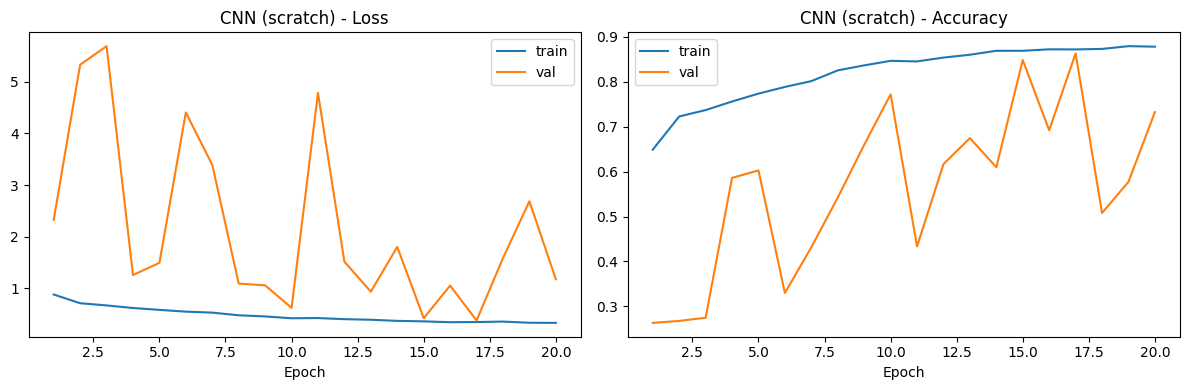

In [17]:
# ===============================================================
# 4) Baseline CNN (from scratch)
#    - Simple, compact CNN with BatchNorm and Dropout.
#    - Input pipeline: Augmentation -> Rescaling(1/255) -> CNN
# ===============================================================
def build_cnn_baseline(input_shape=IMG_SIZE + (3,), classes=num_classes):
    inputs = layers.Input(shape=input_shape)
    x = data_augmentation(inputs)
    x = layers.Rescaling(1./255)(x)

    # Block 1
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    # Block 2
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.25)(x)

    # Block 3
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.25)(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(classes, activation="softmax")(x)
    model = models.Model(inputs, outputs, name="cnn_baseline")
    return model

cnn = build_cnn_baseline()
cnn.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
cnn.summary()

ckpt_cnn = callbacks.ModelCheckpoint(
    "cnn_best.keras", monitor="val_accuracy", mode="max",
    save_best_only=True, verbose=1
)
early = callbacks.EarlyStopping(
    monitor="val_accuracy", mode="max", patience=5, restore_best_weights=True, verbose=1
)

hist_cnn = cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[ckpt_cnn, early],
    verbose=1
)

# Plot training curves
def plot_history(h, title=""):
    epochs = range(1, len(h.history["loss"])+1)
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(epochs, h.history["loss"], label="train")
    plt.plot(epochs, h.history["val_loss"], label="val")
    plt.title(f"{title} - Loss"); plt.xlabel("Epoch"); plt.legend()
    plt.subplot(1,2,2)
    plt.plot(epochs, h.history["accuracy"], label="train")
    plt.plot(epochs, h.history["val_accuracy"], label="val")
    plt.title(f"{title} - Accuracy"); plt.xlabel("Epoch"); plt.legend()
    plt.tight_layout(); plt.show()

plot_history(hist_cnn, "CNN (scratch)")


CNN (scratch) — Test metrics
Accuracy: 0.7826  |  Macro Precision: 0.7939  |  Macro Recall: 0.7660  |  Macro F1: 0.7569

              precision    recall  f1-score   support

      glioma       0.98      0.65      0.78       300
  meningioma       0.67      0.43      0.52       306
     notumor       0.79      0.99      0.88       405
   pituitary       0.74      0.99      0.85       300

    accuracy                           0.78      1311
   macro avg       0.79      0.77      0.76      1311
weighted avg       0.79      0.78      0.77      1311



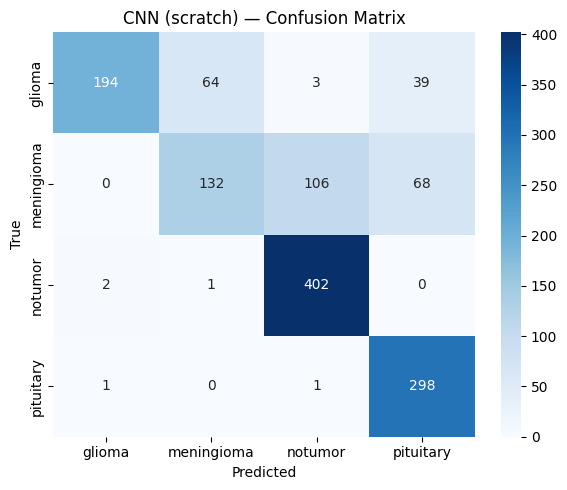

In [18]:
# ===============================================================
# 5) Evaluate helper: accuracy, precision, recall, F1, confusion matrix
#    - Keras' built-in PR metrics are binary-oriented; here we compute with sklearn.
# ===============================================================
def evaluate_model(model, dataset, class_names, title="Model"):
    # Collect predictions & labels
    y_true = []
    y_prob = []
    for batch in dataset:
        images, labels = batch
        preds = model.predict(images, verbose=0)
        y_prob.append(preds)
        y_true.append(labels.numpy())
    y_true = np.concatenate(y_true)
    y_prob = np.concatenate(y_prob)
    y_pred = y_prob.argmax(axis=1)

    acc = (y_true == y_pred).mean()
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    print(f"\n{title} — Test metrics")
    print(f"Accuracy: {acc:.4f}  |  Macro Precision: {p:.4f}  |  Macro Recall: {r:.4f}  |  Macro F1: {f1:.4f}\n")
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f"{title} — Confusion Matrix")
    plt.xlabel("Predicted"); plt.ylabel("True")
    plt.tight_layout(); plt.show()

    return dict(acc=acc, precision=p, recall=r, f1=f1), (y_true, y_pred, y_prob)

# Evaluate baseline CNN on TEST
cnn_metrics, _ = evaluate_model(cnn, test_ds, class_names, title="CNN (scratch)")

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "vgg16_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 14,847,044 (56.64 MB)

 Trainable params: 132,356 (517.02 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/12
142/143 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5333 - loss: 2.3881
Epoch 1: val_accuracy improved from -inf to 0.79422, saving model to vgg_best_frozen.keras
143/143 ━━━━━━━━━━━━━━━━━━━━ 9s 39ms/step - accuracy: 0.5344 - loss: 2.3762 - val_accuracy: 0.7942 - val_loss: 0.5508
Epoch 2/12
142/143 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7141 - loss: 0.7608
Epoch 2: val_accuracy improved from 0.79422 to 0.81524, saving model to vgg_best_frozen.keras
143/143 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.7143 - loss: 0.7604 - val_accuracy: 0.8152 - val_loss: 0.4878
Epoch 3/12
142/143 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7695 - loss: 0.6306
Epoch 3: val_accuracy improved from 0.81524 to 0.85026, saving model to vgg_best_frozen.keras
143/143 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.7696 - loss: 0.6304 - val_accuracy: 0.8503 - val_loss: 0.4467
Epoch 4/12
142/143 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7741 - loss: 0.5921
Epoch 4: val_accura

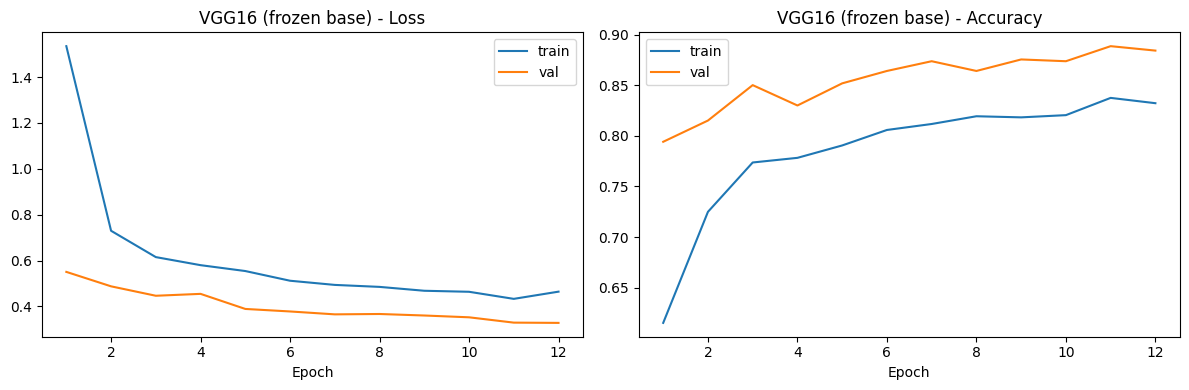


VGG16 (frozen base) — Test metrics
Accuracy: 0.8635  |  Macro Precision: 0.8583  |  Macro Recall: 0.8572  |  Macro F1: 0.8547

              precision    recall  f1-score   support

      glioma       0.89      0.79      0.84       300
  meningioma       0.78      0.71      0.74       306
     notumor       0.95      0.94      0.95       405
   pituitary       0.81      0.98      0.89       300

    accuracy                           0.86      1311
   macro avg       0.86      0.86      0.85      1311
weighted avg       0.87      0.86      0.86      1311



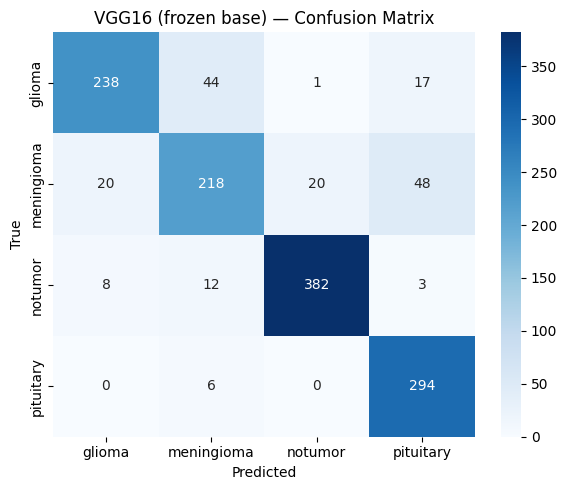

Epoch 1/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.8565 - loss: 0.4111
Epoch 1: val_accuracy improved from -inf to 0.89930, saving model to vgg_best_finetuned.keras
143/143 ━━━━━━━━━━━━━━━━━━━━ 21s 91ms/step - accuracy: 0.8566 - loss: 0.4109 - val_accuracy: 0.8993 - val_loss: 0.2858
Epoch 2/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.8853 - loss: 0.3017
Epoch 2: val_accuracy did not improve from 0.89930
143/143 ━━━━━━━━━━━━━━━━━━━━ 10s 63ms/step - accuracy: 0.8854 - loss: 0.3016 - val_accuracy: 0.8958 - val_loss: 0.3375
Epoch 3/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.9221 - loss: 0.2202
Epoch 3: val_accuracy improved from 0.89930 to 0.94046, saving model to vgg_best_finetuned.keras
143/143 ━━━━━━━━━━━━━━━━━━━━ 11s 68ms/step - accuracy: 0.9221 - loss: 0.2203 - val_accuracy: 0.9405 - val_loss: 0.1796
Epoch 4/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.9284 - loss: 0.1851
Epoch 4: val_accuracy did not improve from 0.94046
14

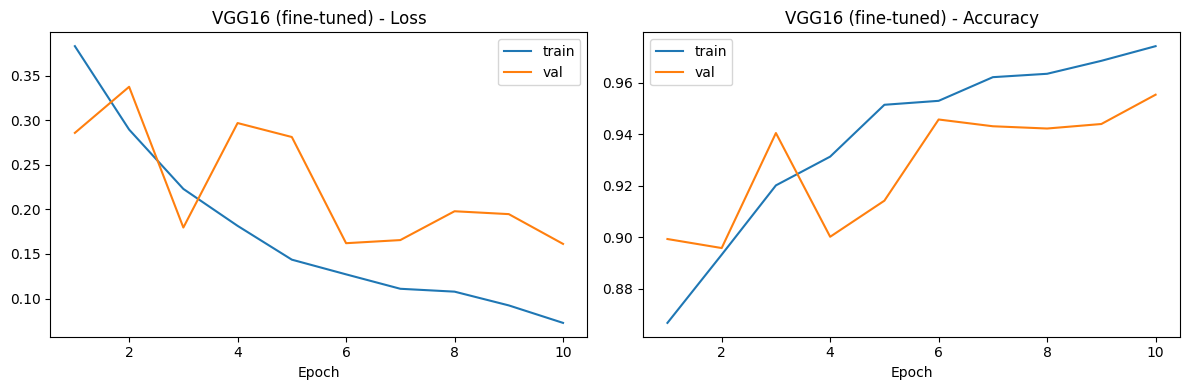


VGG16 (fine-tuned) — Test metrics
Accuracy: 0.9588  |  Macro Precision: 0.9580  |  Macro Recall: 0.9565  |  Macro F1: 0.9563

              precision    recall  f1-score   support

      glioma       0.99      0.93      0.96       300
  meningioma       0.95      0.91      0.93       306
     notumor       0.99      0.99      0.99       405
   pituitary       0.90      1.00      0.95       300

    accuracy                           0.96      1311
   macro avg       0.96      0.96      0.96      1311
weighted avg       0.96      0.96      0.96      1311



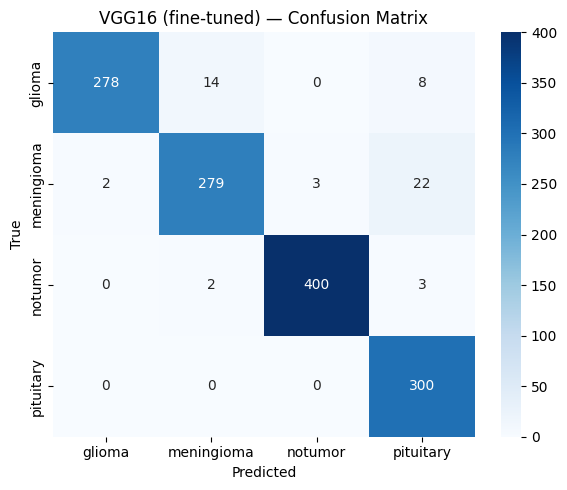

In [19]:
# ===============================================================
# 6) Transfer Learning with VGG16
#    - Expect stronger performance on limited data.
#    - Preprocessing: use VGG16 preprocess_input
# ===============================================================
def build_vgg16_transfer(input_shape=IMG_SIZE + (3,), classes=num_classes, train_base=False):
    inputs = layers.Input(shape=input_shape)
    x = data_augmentation(inputs)               # augmentation (train only)
    x = layers.Lambda(vgg_preprocess)(x)        # VGG16 expects BGR channels and specific scaling

    base = VGG16(include_top=False, weights="imagenet", input_tensor=x)
    base.trainable = train_base                 # start frozen

    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(classes, activation="softmax")(x)
    model = models.Model(inputs, outputs, name="vgg16_transfer")
    return model

# Phase 1: Frozen base (feature extraction)
vgg = build_vgg16_transfer(train_base=False)
vgg.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
vgg.summary()

ckpt_vgg = callbacks.ModelCheckpoint(
    "vgg_best_frozen.keras", monitor="val_accuracy", mode="max",
    save_best_only=True, verbose=1
)
early_vgg = callbacks.EarlyStopping(
    monitor="val_accuracy", mode="max", patience=4, restore_best_weights=True, verbose=1
)

hist_vgg = vgg.fit(
    train_ds,
    validation_data=val_ds,
    epochs=12,
    callbacks=[ckpt_vgg, early_vgg],
    verbose=1
)
plot_history(hist_vgg, "VGG16 (frozen base)")

vgg_frozen_metrics, _ = evaluate_model(vgg, test_ds, class_names, title="VGG16 (frozen base)")

# Phase 2 (optional): Fine-tune top VGG16 blocks at low LR
# Unfreeze last convolutional block (e.g., block5) for slight adaptation
for layer in vgg.layers:
    if isinstance(layer, tf.keras.layers.Conv2D) or "block5" in layer.name:
        layer.trainable = True
    else:
        # Keep earlier layers frozen to avoid overfitting
        if "block5" not in layer.name and isinstance(layer, tf.keras.layers.Layer):
            if hasattr(layer, "trainable"):
                layer.trainable = False

vgg.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

ckpt_vgg_ft = callbacks.ModelCheckpoint(
    "vgg_best_finetuned.keras", monitor="val_accuracy", mode="max",
    save_best_only=True, verbose=1
)
early_vgg_ft = callbacks.EarlyStopping(
    monitor="val_accuracy", mode="max", patience=4, restore_best_weights=True, verbose=1
)

hist_vgg_ft = vgg.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[ckpt_vgg_ft, early_vgg_ft],
    verbose=1
)
plot_history(hist_vgg_ft, "VGG16 (fine-tuned)")

vgg_ft_metrics, _ = evaluate_model(vgg, test_ds, class_names, title="VGG16 (fine-tuned)")

In [20]:
# ===============================================================
# 7) Side-by-side comparison & notes
#    - We pay special attention to Recall to reduce false negatives.
# ===============================================================
def summarize_results(cnn_m, vgg_frozen_m, vgg_ft_m):
    rows = [
        ("CNN (scratch)",    cnn_m["acc"],       cnn_m["precision"],    cnn_m["recall"],    cnn_m["f1"]),
        ("VGG16 (frozen)",   vgg_frozen_m["acc"],vgg_frozen_m["precision"],vgg_frozen_m["recall"],vgg_frozen_m["f1"]),
        ("VGG16 (finetune)", vgg_ft_m["acc"],    vgg_ft_m["precision"], vgg_ft_m["recall"], vgg_ft_m["f1"]),
    ]
    df = pd.DataFrame(rows, columns=["Model","Accuracy","Macro Precision","Macro Recall","Macro F1"])
    return df

summary_df = summarize_results(cnn_metrics, vgg_frozen_metrics, vgg_ft_metrics)
print("\n=== Summary (higher is better) ===")
# Format only the numeric columns
numeric_cols = ["Accuracy","Macro Precision","Macro Recall","Macro F1"]
display(summary_df.style.format({col: "{:.4f}" for col in numeric_cols}))


=== Summary (higher is better) ===


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,CNN (scratch),0.7826,0.7939,0.7660,0.7569
1,VGG16 (frozen),0.8635,0.8583,0.8572,0.8547
2,VGG16 (finetune),0.9588,0.9580,0.9565,0.9563



CNN sample predictions:


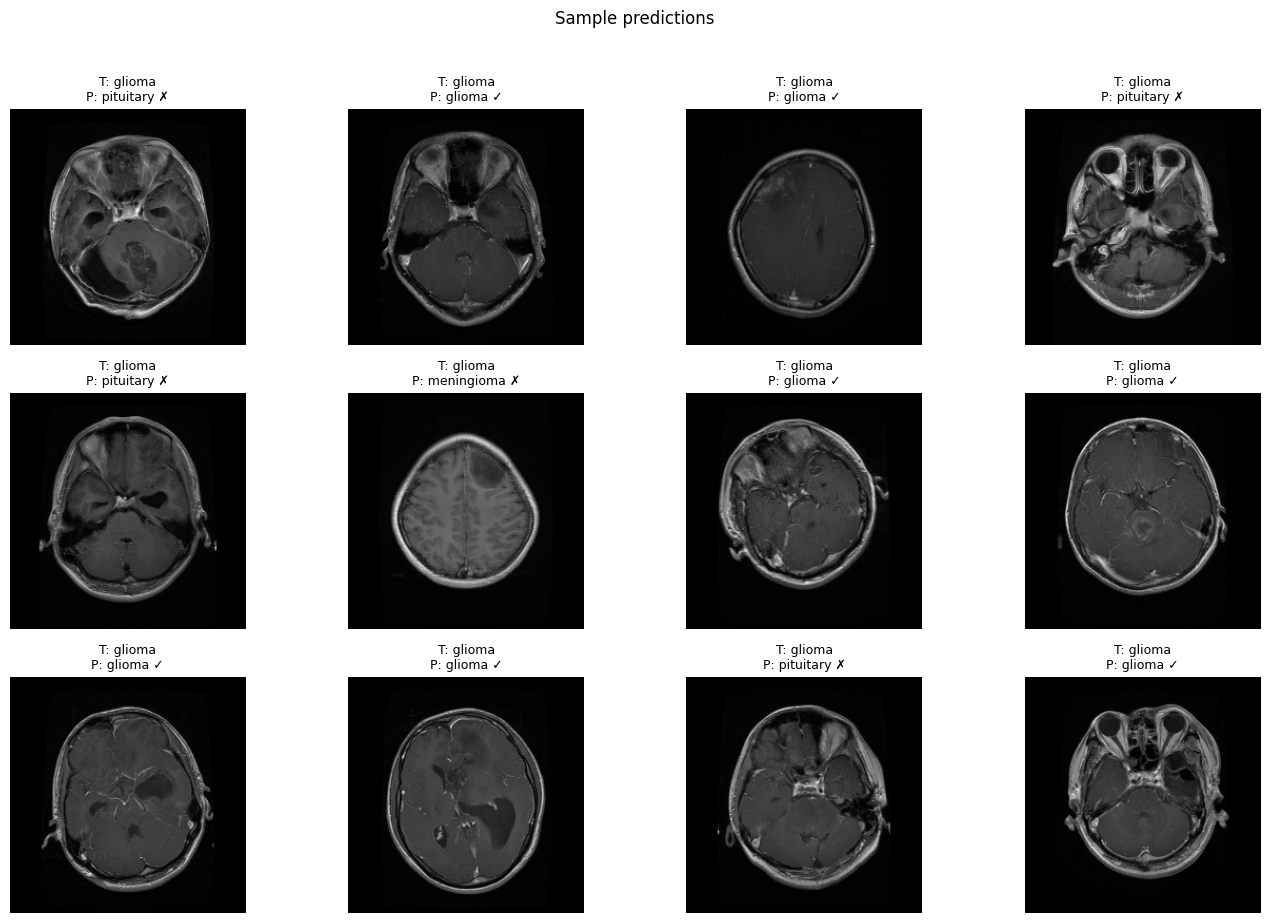


VGG16 (fine-tuned) sample predictions:


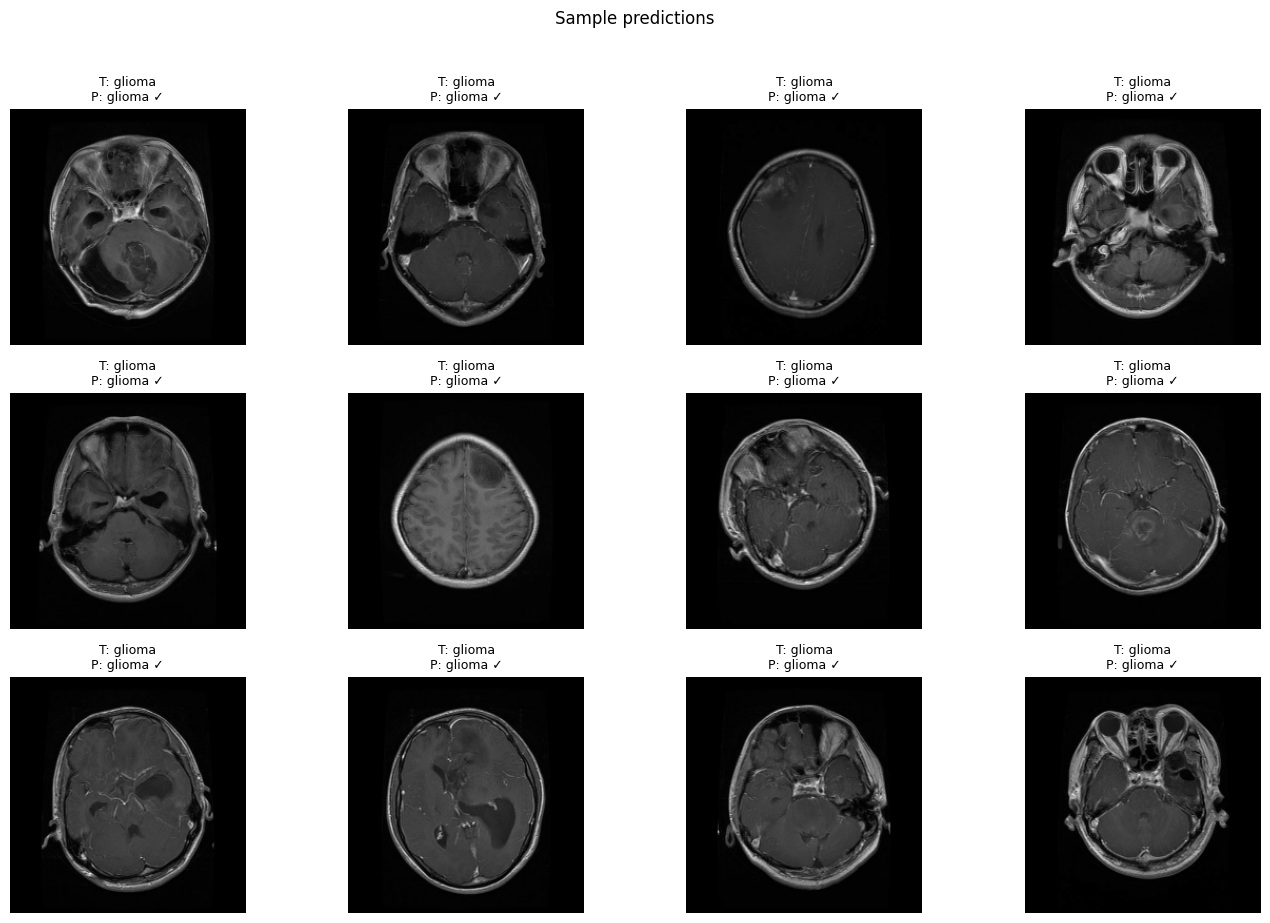

In [21]:




# ===============================================================
# 8) Qualitative inspection — view some predictions
# ===============================================================
def show_predictions(model, dataset, class_names, n=12):
    # Grab one batch
    for images, labels in dataset.take(1):
        probs = model.predict(images, verbose=0)
        preds = probs.argmax(axis=1)
        plt.figure(figsize=(14, 9))
        for i in range(min(n, images.shape[0])):
            plt.subplot(math.ceil(n/4), 4, i+1)
            plt.imshow(images[i].numpy().astype("uint8"))
            plt.axis("off")
            t = class_names[labels[i].numpy()]
            p = class_names[preds[i]]
            c = "✓" if t == p else "✗"
            plt.title(f"T: {t}\nP: {p} {c}", fontsize=9)
        plt.suptitle("Sample predictions", y=1.02)
        plt.tight_layout(); plt.show()
        break

print("\nCNN sample predictions:")
show_predictions(cnn, test_ds, class_names, n=12)

print("\nVGG16 (fine-tuned) sample predictions:")
show_predictions(vgg, test_ds, class_names, n=12)

